# FocusVision  Salient Object Detection

This notebook contains the complete deep learning pipeline for salient object detection using a custom CNN model built with PyTorch

# Project Setup

In this section, we initialize the environment and verify GPU availability for deep learning training


In [7]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No GPU found")

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


# Google Drive Connection

In this step, we connect Google Drive to access datasets, save trained models, and store project results

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Project Directory Setup

In this section, we create the necessary project folders inside Google Drive for datasets, trained models, and results


In [9]:
import os

project_path = "/content/drive/MyDrive/FocusVision"

folders = [
    "data",
    "models",
    "results"
]

for folder in folders:
    os.makedirs(os.path.join(project_path, folder), exist_ok=True)

print("Project folders created successfully")

Project folders created successfully


In [10]:
import os

print(os.listdir('/content/drive/MyDrive'))

['Colab Notebooks', 'FocusVision']


In [11]:
import os

data_path = "/content/drive/MyDrive/FocusVision/data"

print(os.listdir(data_path))

[]


# Dataset Preparation

For this project, we use the ECSSD dataset for salient object detection.  
The dataset contains natural images and corresponding ground truth masks

# Dataset Download

In this step, we download and extract the ECSSD dataset for salient object detection training

In [12]:
import os
import gdown
import zipfile

# Dataset Extraction

In this step, we extract the dataset files from ZIP archives into the project data directory


In [14]:
import zipfile
import os

data_path = "/content/drive/MyDrive/FocusVision/data"

zip_files = [
    "images.zip",
    "ground_truth_mask.zip"
]

for zip_file in zip_files:
    zip_path = os.path.join(data_path, zip_file)

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(data_path)

    print(f"{zip_file} extracted successfully")

images.zip extracted successfully
ground_truth_mask.zip extracted successfully


# Dataset Exploration

In this step, we inspect the extracted dataset structure and verify that images and ground truth masks are loaded correctly

In [15]:
data_path = "/content/drive/MyDrive/FocusVision/data"

print(os.listdir(data_path))

['ground_truth_mask.zip', 'images.zip', 'images', 'ground_truth_mask']


In [16]:
images_dir = os.path.join(data_path, "images")
masks_dir = os.path.join(data_path, "ground_truth_mask")

image_files = sorted(os.listdir(images_dir))
mask_files = sorted(os.listdir(masks_dir))

print("Number of images:", len(image_files))
print("Number of masks:", len(mask_files))

print("First 5 image files:", image_files[:5])
print("First 5 mask files:", mask_files[:5])

Number of images: 1000
Number of masks: 1000
First 5 image files: ['0001.jpg', '0002.jpg', '0003.jpg', '0004.jpg', '0005.jpg']
First 5 mask files: ['0001.png', '0002.png', '0003.png', '0004.png', '0005.png']


# Sample Visualization

In this section we visualize sample images and their corresponding ground truth masks from the ECSSD dataset


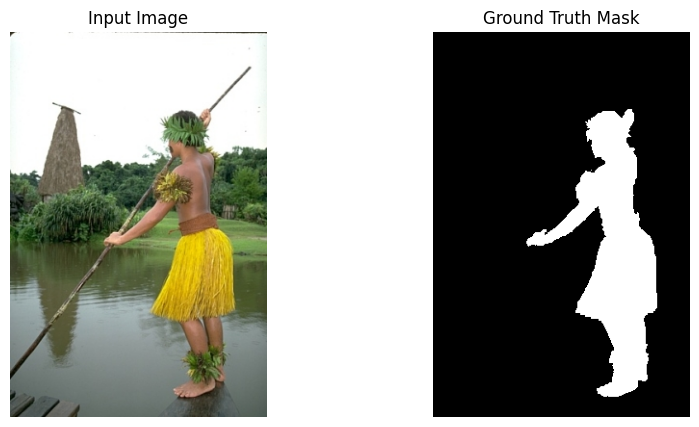

In [17]:
import matplotlib.pyplot as plt
from PIL import Image

sample_index = 0

image_path = os.path.join(images_dir, image_files[sample_index])
mask_path = os.path.join(masks_dir, mask_files[sample_index])

image = Image.open(image_path)
mask = Image.open(mask_path)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Input Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap="gray")
plt.title("Ground Truth Mask")
plt.axis("off")

plt.show()

# Image Preprocessing and Augmentation

In this section, we define preprocessing and augmentation transformations for training the CNN model

In [18]:
from torchvision import transforms

IMAGE_SIZE = 224

In [19]:
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

In [20]:
from torchvision import transforms

IMAGE_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

print("Transformations created successfully")

Transformations created successfully


# Custom Dataset Class

In this section, we create a custom PyTorch dataset class to load images and corresponding ground truth masks

In [21]:
from torch.utils.data import Dataset

class SaliencyDataset(Dataset):

    def __init__(self, images_dir, masks_dir, image_files, mask_files, transform=None):

        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.image_files = image_files
        self.mask_files = mask_files
        self.transform = transform

    def __len__(self):

        return len(self.image_files)

    def __getitem__(self, index):

        image_path = os.path.join(self.images_dir, self.image_files[index])
        mask_path = os.path.join(self.masks_dir, self.mask_files[index])

        image = Image.open(image_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        if self.transform:
            image = self.transform(image)
            mask = self.transform(mask)

        return image, mask

In [22]:
from sklearn.model_selection import train_test_split

train_images, val_images, train_masks, val_masks = train_test_split(
    image_files,
    mask_files,
    test_size=0.2,
    random_state=42
)

print("Training images:", len(train_images))
print("Validation images:", len(val_images))
print("Training masks:", len(train_masks))
print("Validation masks:", len(val_masks))

Training images: 800
Validation images: 200
Training masks: 800
Validation masks: 200


In [23]:
train_dataset = SaliencyDataset(
    images_dir=images_dir,
    masks_dir=masks_dir,
    image_files=train_images,
    mask_files=train_masks,
    transform=train_transform
)

val_dataset = SaliencyDataset(
    images_dir=images_dir,
    masks_dir=masks_dir,
    image_files=val_images,
    mask_files=val_masks,
    transform=val_transform
)

print("Train dataset size:", len(train_dataset))
print("Validation dataset size:", len(val_dataset))

Train dataset size: 800
Validation dataset size: 200


# Data Loaders

In this section, we create PyTorch data loaders for efficient batch processing during model training and validation

In [24]:
from torch.utils.data import DataLoader

BATCH_SIZE = 8

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Train loader batches:", len(train_loader))
print("Validation loader batches:", len(val_loader))

Train loader batches: 100
Validation loader batches: 25


# CNN Model Architecture

In this section, we build a custom encoder-decoder convolutional neural network for salient object detection

In [25]:
import torch.nn as nn

In [26]:
class FocusVisionCNN(nn.Module):

    def __init__(self):
        super(FocusVisionCNN, self).__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2),
            nn.ReLU(),

            nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2),
            nn.ReLU(),

            nn.ConvTranspose2d(16, 1, kernel_size=2, stride=2),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [27]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = FocusVisionCNN().to(device)

print("Using device:", device)
print(model)

Using device: cuda
FocusVisionCNN(
  (encoder): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(64, 32, kernel_size=(2, 2), stride=(2, 2))
    (1): ReLU()
    (2): ConvTranspose2d(32, 16, kernel_size=(2, 2), stride=(2, 2))
    (3): ReLU()
    (4): ConvTranspose2d(16, 1, kernel_size=(2, 2), stride=(2, 2))
    (5): Sigmoid()
  )
)


# Loss Function and Optimizer

In this section, we define the loss function and optimizer used to train the CNN model

In [28]:
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("Loss function and optimizer are ready")

Loss function and optimizer are ready


# Training Configuration

In this section, we define the training settings and prepare the model training loop

In [29]:
EPOCHS = 5

train_losses = []
val_losses = []

print("Training configuration initialized")

Training configuration initialized


In [30]:
from tqdm import tqdm

for epoch in range(EPOCHS):
    model.train()
    running_train_loss = 0.0

    for images, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} - Training"):
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, masks)

        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for images, masks in tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} - Validation"):
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            loss = criterion(outputs, masks)

            running_val_loss += loss.item()

    avg_val_loss = running_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch [{epoch+1}/{EPOCHS}] - Train Loss: {avg_train_loss:.4f} - Val Loss: {avg_val_loss:.4f}")

Epoch 1/5 - Validation: 100%|██████████| 25/25 [00:03<00:00,  7.69it/s]


Epoch [1/5] - Train Loss: 0.5678 - Val Loss: 0.5428


Epoch 2/5 - Validation: 100%|██████████| 25/25 [00:03<00:00,  8.08it/s]


Epoch [2/5] - Train Loss: 0.5339 - Val Loss: 0.5281


Epoch 3/5 - Validation: 100%|██████████| 25/25 [00:02<00:00,  8.79it/s]


Epoch [3/5] - Train Loss: 0.5229 - Val Loss: 0.5154


Epoch 4/5 - Validation: 100%|██████████| 25/25 [00:02<00:00, 10.24it/s]


Epoch [4/5] - Train Loss: 0.5086 - Val Loss: 0.4959


Epoch 5/5 - Validation: 100%|██████████| 25/25 [00:02<00:00,  9.63it/s]

Epoch [5/5] - Train Loss: 0.5036 - Val Loss: 0.4931


# Training Performance Visualization

In this section, we visualize the training and validation loss curves across epochs

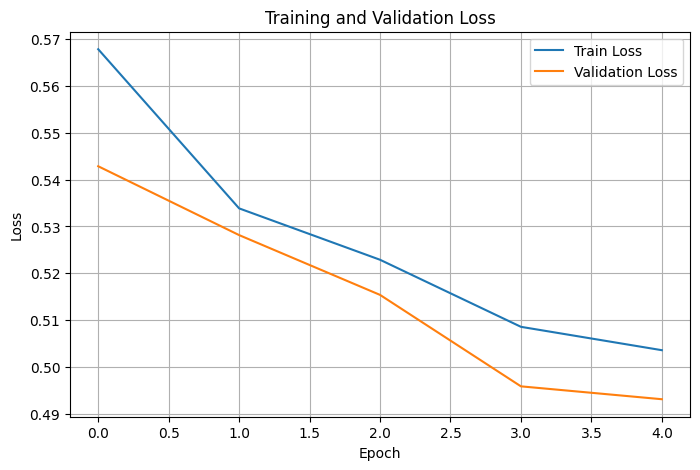

In [31]:
plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)

plt.show()

# Model Prediction Visualization

In this section, we generate predictions using the trained CNN model and compare them with the ground truth masks

In [32]:
model.eval()

print("Model switched to evaluation mode")

Model switched to evaluation mode


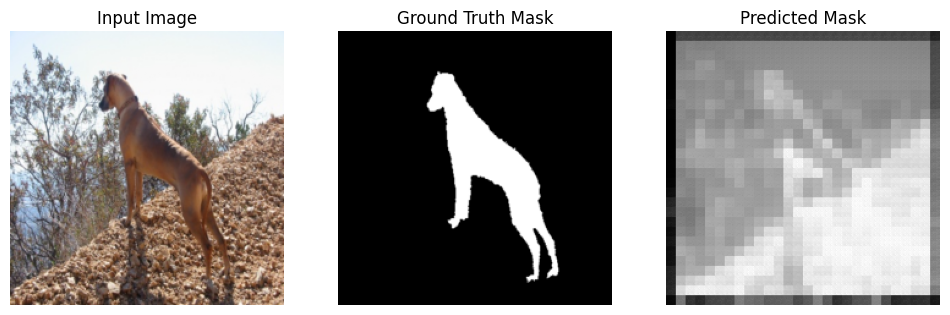

In [33]:
sample_image, sample_mask = val_dataset[0]

input_image = sample_image.unsqueeze(0).to(device)

with torch.no_grad():
    predicted_mask = model(input_image)

predicted_mask = predicted_mask.squeeze().cpu()

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(sample_image.permute(1, 2, 0))
plt.title("Input Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(sample_mask.squeeze(), cmap="gray")
plt.title("Ground Truth Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(predicted_mask, cmap="gray")
plt.title("Predicted Mask")
plt.axis("off")

plt.show()

# Saving the Trained Model

In this section, we save the trained CNN model for future inference and evaluation

In [34]:
model_save_path = "/content/drive/MyDrive/FocusVision/models/focusvision_model.pth"

torch.save(model.state_dict(), model_save_path)

print("Model saved successfully")

Model saved successfully


# Multiple Prediction Examples

In this section, we visualize multiple model predictions on validation images to evaluate the performance of the CNN model

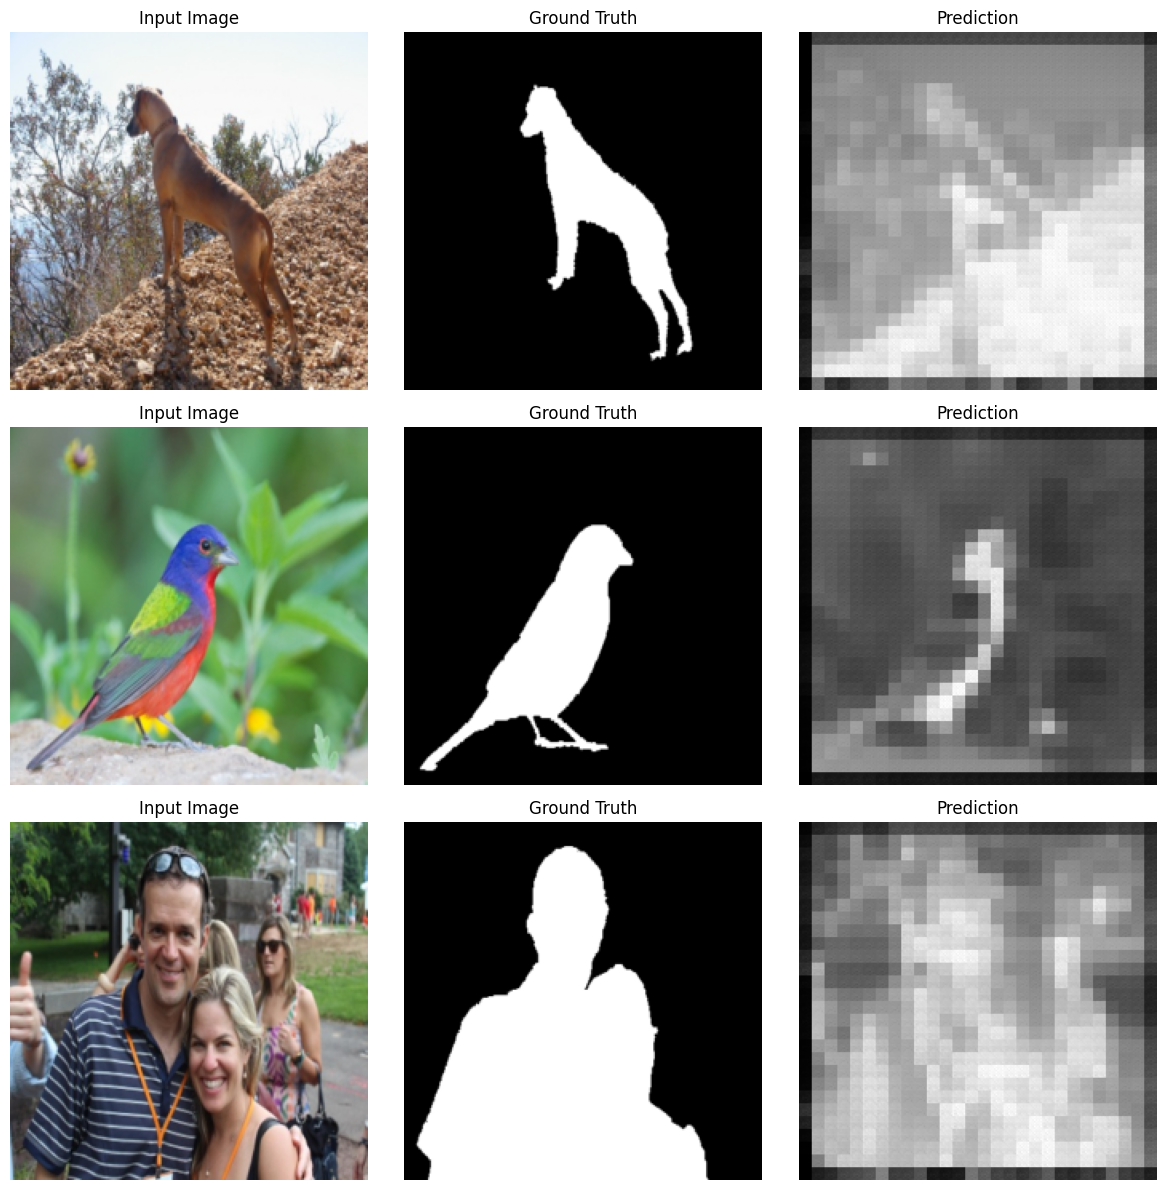

In [35]:
num_samples = 3

plt.figure(figsize=(12, 12))

for i in range(num_samples):

    sample_image, sample_mask = val_dataset[i]

    input_image = sample_image.unsqueeze(0).to(device)

    with torch.no_grad():
        predicted_mask = model(input_image)

    predicted_mask = predicted_mask.squeeze().cpu()

    plt.subplot(num_samples, 3, i * 3 + 1)
    plt.imshow(sample_image.permute(1, 2, 0))
    plt.title("Input Image")
    plt.axis("off")

    plt.subplot(num_samples, 3, i * 3 + 2)
    plt.imshow(sample_mask.squeeze(), cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(num_samples, 3, i * 3 + 3)
    plt.imshow(predicted_mask, cmap="gray")
    plt.title("Prediction")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Evaluation Metrics Preparation

In this section, we prepare predicted masks for evaluation using binary thresholding

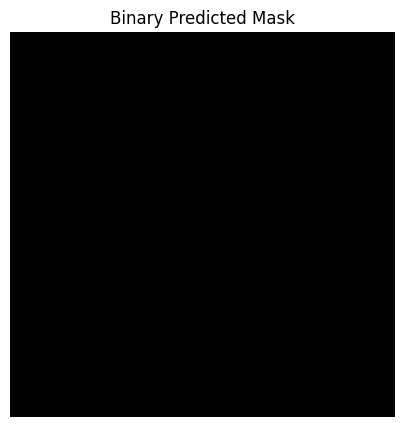

In [41]:
predicted_binary = (predicted_mask > 0.5).float()

plt.figure(figsize=(5, 5))

plt.imshow(predicted_binary, cmap="gray")
plt.title("Binary Predicted Mask")
plt.axis("off")

plt.show()

# BCE + IoU Loss

In this section, we define a combined loss function using Binary Cross Entropy and Intersection-over-Union loss

In [38]:
class BCEDiceIoULoss(nn.Module):

    def __init__(self):
        super(BCEDiceIoULoss, self).__init__()

        self.bce = nn.BCELoss()

    def forward(self, predictions, targets):

        bce_loss = self.bce(predictions, targets)

        smooth = 1e-6

        predictions_flat = predictions.view(-1)
        targets_flat = targets.view(-1)

        intersection = (predictions_flat * targets_flat).sum()

        union = predictions_flat.sum() + targets_flat.sum() - intersection

        iou = (intersection + smooth) / (union + smooth)

        iou_loss = 1 - iou

        total_loss = bce_loss + iou_loss

        return total_loss

# Improved Training Setup

In this section, we reinitialize the model and train it again using the combined BCE + IoU loss


In [39]:
improved_model = FocusVisionCNN().to(device)

improved_criterion = BCEDiceIoULoss()
improved_optimizer = torch.optim.Adam(improved_model.parameters(), lr=0.001)

improved_train_losses = []
improved_val_losses = []

IMPROVED_EPOCHS = 15

print("Improved model training setup is ready")

Improved model training setup is ready


In [40]:
from tqdm import tqdm

for epoch in range(IMPROVED_EPOCHS):
    improved_model.train()
    running_train_loss = 0.0

    for images, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{IMPROVED_EPOCHS} - Training"):
        images = images.to(device)
        masks = masks.to(device)

        improved_optimizer.zero_grad()

        outputs = improved_model(images)
        loss = improved_criterion(outputs, masks)

        loss.backward()
        improved_optimizer.step()

        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / len(train_loader)
    improved_train_losses.append(avg_train_loss)

    improved_model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for images, masks in tqdm(val_loader, desc=f"Epoch {epoch+1}/{IMPROVED_EPOCHS} - Validation"):
            images = images.to(device)
            masks = masks.to(device)

            outputs = improved_model(images)
            loss = improved_criterion(outputs, masks)

            running_val_loss += loss.item()

    avg_val_loss = running_val_loss / len(val_loader)
    improved_val_losses.append(avg_val_loss)

    print(f"Epoch [{epoch+1}/{IMPROVED_EPOCHS}] - Train Loss: {avg_train_loss:.4f} - Val Loss: {avg_val_loss:.4f}")

Epoch 1/15 - Validation: 100%|██████████| 25/25 [00:02<00:00,  9.24it/s]


Epoch [1/15] - Train Loss: 1.4536 - Val Loss: 1.3975


Epoch 2/15 - Validation: 100%|██████████| 25/25 [00:02<00:00, 10.17it/s]


Epoch [2/15] - Train Loss: 1.3794 - Val Loss: 1.3807


Epoch 3/15 - Validation: 100%|██████████| 25/25 [00:02<00:00, 11.25it/s]


...

Epoch [13/15] - Train Loss: 1.2977 - Val Loss: 1.2721


Epoch 14/15 - Validation: 100%|██████████| 25/25 [00:02<00:00,  9.69it/s]


Epoch [14/15] - Train Loss: 1.2905 - Val Loss: 1.2625


Epoch 15/15 - Validation: 100%|██████████| 25/25 [00:02<00:00,  8.66it/s]

Epoch [15/15] - Train Loss: 1.2878 - Val Loss: 1.2699


# Improved Training Performance

In this section, we visualize the training and validation loss after training the model with BCE + IoU loss

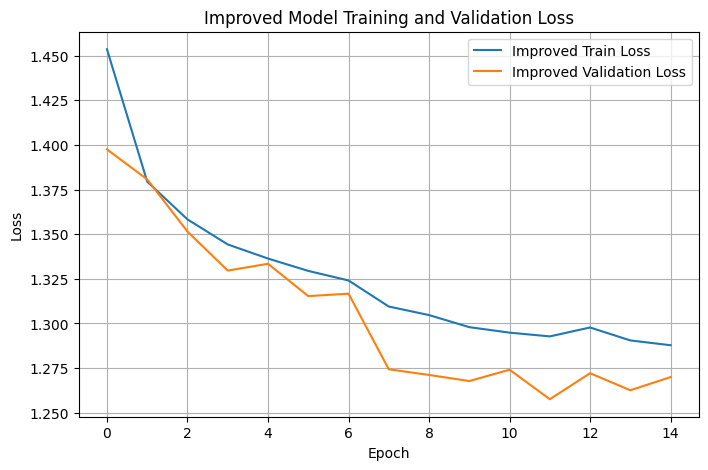

In [42]:
plt.figure(figsize=(8, 5))

plt.plot(improved_train_losses, label="Improved Train Loss")
plt.plot(improved_val_losses, label="Improved Validation Loss")

plt.title("Improved Model Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)

plt.show()

# Improved Prediction Results

In this section, we visualize predictions generated by the improved CNN model trained with BCE + IoU loss

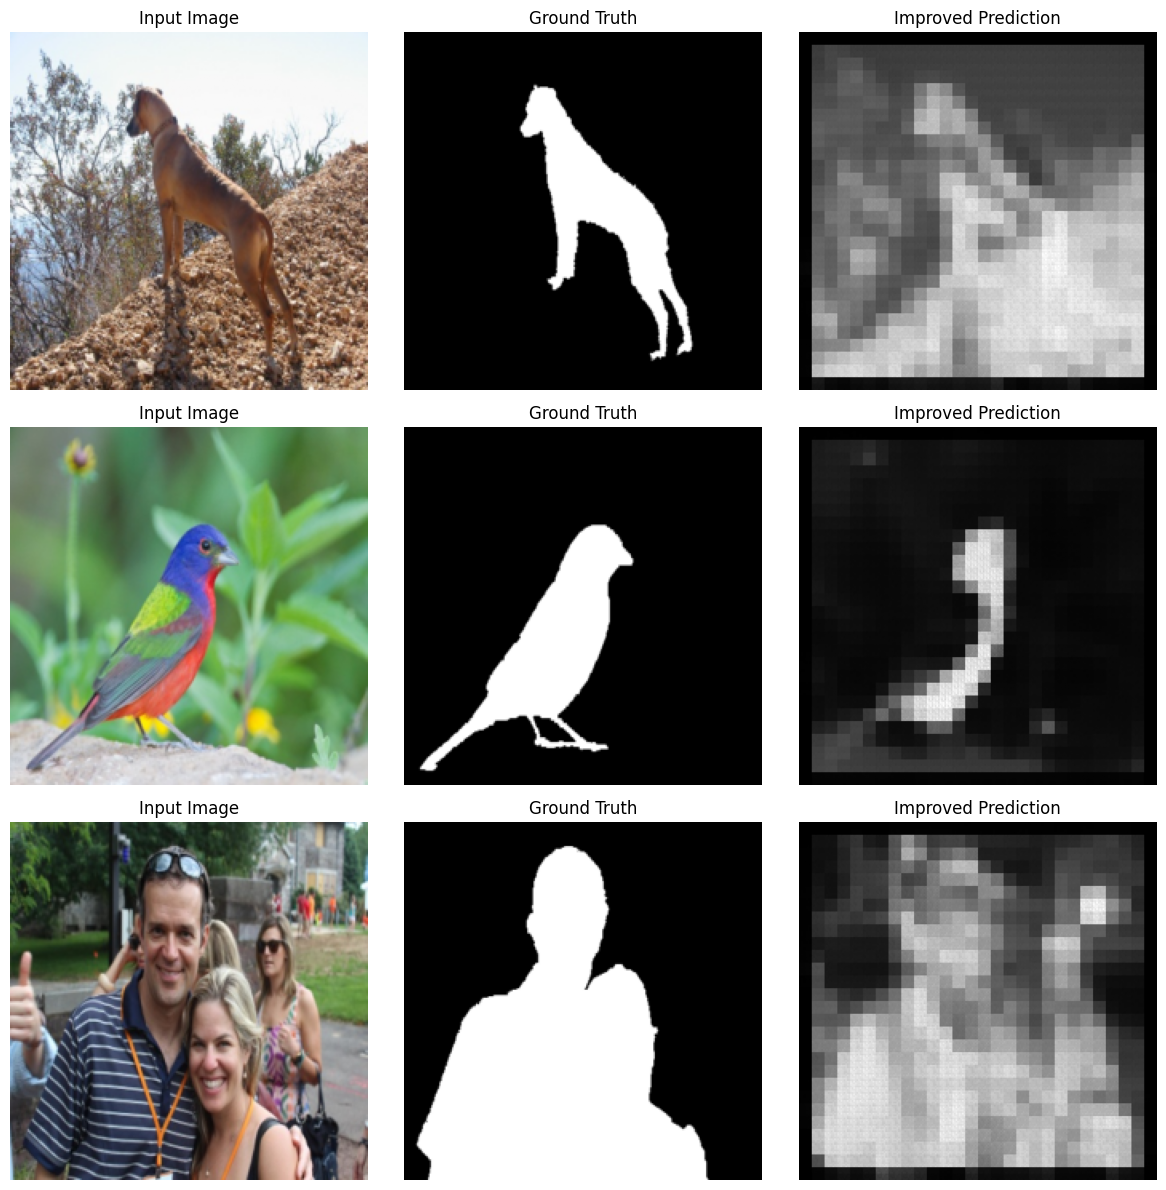

In [43]:
improved_model.eval()

num_samples = 3

plt.figure(figsize=(12, 12))

for i in range(num_samples):

    sample_image, sample_mask = val_dataset[i]

    input_image = sample_image.unsqueeze(0).to(device)

    with torch.no_grad():
        predicted_mask = improved_model(input_image)

    predicted_mask = predicted_mask.squeeze().cpu()

    plt.subplot(num_samples, 3, i * 3 + 1)
    plt.imshow(sample_image.permute(1, 2, 0))
    plt.title("Input Image")
    plt.axis("off")

    plt.subplot(num_samples, 3, i * 3 + 2)
    plt.imshow(sample_mask.squeeze(), cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(num_samples, 3, i * 3 + 3)
    plt.imshow(predicted_mask, cmap="gray")
    plt.title("Improved Prediction")
    plt.axis("off")

plt.tight_layout()
plt.show()

# IoU Evaluation Metric

In this section, we calculate the Intersection-over-Union (IoU) score for the improved model predictions

In [44]:
def calculate_iou(prediction, target, threshold=0.5):

    prediction = (prediction > threshold).float()

    prediction = prediction.view(-1)
    target = target.view(-1)

    intersection = (prediction * target).sum()
    union = prediction.sum() + target.sum() - intersection

    smooth = 1e-6

    iou = (intersection + smooth) / (union + smooth)

    return iou.item()

In [45]:
improved_model.eval()

iou_scores = []

with torch.no_grad():

    for images, masks in val_loader:

        images = images.to(device)
        masks = masks.to(device)

        predictions = improved_model(images)

        batch_iou = calculate_iou(predictions, masks)

        iou_scores.append(batch_iou)

average_iou = sum(iou_scores) / len(iou_scores)

print(f"Average IoU Score: {average_iou:.4f}")

Average IoU Score: 0.1738


# Precision, Recall and F1 Evaluation

In this section, we evaluate the improved model using Precision, Recall, and F1-score metrics

In [46]:
from sklearn.metrics import precision_score, recall_score, f1_score

In [51]:
all_predictions = []
all_targets = []

improved_model.eval()

with torch.no_grad():

    for images, masks in val_loader:

        images = images.to(device)
        masks = masks.to(device)

        predictions = improved_model(images)

        predictions = (predictions > 0.5).float()

        all_predictions.extend(predictions.cpu().numpy().flatten())
        all_targets.extend(masks.cpu().numpy().flatten())

In [52]:
all_predictions = []
all_targets = []

improved_model.eval()

with torch.no_grad():

    for images, masks in val_loader:

        images = images.to(device)
        masks = masks.to(device)

        predictions = improved_model(images)

        predictions = (predictions > 0.5).float()
        masks = (masks > 0.5).float()

        all_predictions.extend(predictions.cpu().numpy().flatten())
        all_targets.extend(masks.cpu().numpy().flatten())

precision = precision_score(all_targets, all_predictions, zero_division=0)
recall = recall_score(all_targets, all_predictions, zero_division=0)
f1 = f1_score(all_targets, all_predictions, zero_division=0)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Precision: 0.5282
Recall: 0.1956
F1 Score: 0.2854


# Advanced CNN Architecture Experiment

After training and evaluating the first CNN model, I decided to experiment with a slightly deeper architecture to see if the segmentation masks could become more accurate and focused. In this version, Batch Normalization and skip connections are added to improve feature learning and help the model preserve more spatial information during reconstruction

In [53]:
class DoubleConv(nn.Module):

    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU()
        )

    def forward(self, x):
        return self.conv(x)

In [54]:
class FocusVisionAdvancedCNN(nn.Module):

    def __init__(self):
        super(FocusVisionAdvancedCNN, self).__init__()

        self.encoder1 = DoubleConv(3, 32)
        self.pool1 = nn.MaxPool2d(2)

        self.encoder2 = DoubleConv(32, 64)
        self.pool2 = nn.MaxPool2d(2)

        self.encoder3 = DoubleConv(64, 128)
        self.pool3 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(128, 256)

        self.upconv3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.decoder3 = DoubleConv(256, 128)

        self.upconv2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.decoder2 = DoubleConv(128, 64)

        self.upconv1 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.decoder1 = DoubleConv(64, 32)

        self.final_conv = nn.Conv2d(32, 1, kernel_size=1)

    def forward(self, x):

        enc1 = self.encoder1(x)
        enc2 = self.encoder2(self.pool1(enc1))
        enc3 = self.encoder3(self.pool2(enc2))

        bottleneck = self.bottleneck(self.pool3(enc3))

        dec3 = self.upconv3(bottleneck)
        dec3 = torch.cat((dec3, enc3), dim=1)
        dec3 = self.decoder3(dec3)

        dec2 = self.upconv2(dec3)
        dec2 = torch.cat((dec2, enc2), dim=1)
        dec2 = self.decoder2(dec2)

        dec1 = self.upconv1(dec2)
        dec1 = torch.cat((dec1, enc1), dim=1)
        dec1 = self.decoder1(dec1)

        return torch.sigmoid(self.final_conv(dec1))

In [56]:
advanced_model = FocusVisionAdvancedCNN().to(device)

advanced_criterion = BCEDiceIoULoss()
advanced_optimizer = torch.optim.Adam(advanced_model.parameters(), lr=0.001)

advanced_train_losses = []
advanced_val_losses = []

ADVANCED_EPOCHS = 20

print("Advanced model training setup is ready")

Advanced model training setup is ready


In [57]:
from tqdm import tqdm

for epoch in range(ADVANCED_EPOCHS):

    advanced_model.train()
    running_train_loss = 0.0

    for images, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{ADVANCED_EPOCHS} - Training"):

        images = images.to(device)
        masks = masks.to(device)

        advanced_optimizer.zero_grad()

        outputs = advanced_model(images)

        loss = advanced_criterion(outputs, masks)

        loss.backward()

        advanced_optimizer.step()

        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / len(train_loader)
    advanced_train_losses.append(avg_train_loss)

    advanced_model.eval()
    running_val_loss = 0.0

    with torch.no_grad():

        for images, masks in tqdm(val_loader, desc=f"Epoch {epoch+1}/{ADVANCED_EPOCHS} - Validation"):

            images = images.to(device)
            masks = masks.to(device)

            outputs = advanced_model(images)

            loss = advanced_criterion(outputs, masks)

            running_val_loss += loss.item()

    avg_val_loss = running_val_loss / len(val_loader)
    advanced_val_losses.append(avg_val_loss)

    print(f"Epoch [{epoch+1}/{ADVANCED_EPOCHS}] - Train Loss: {avg_train_loss:.4f} - Val Loss: {avg_val_loss:.4f}")

Epoch 1/20 - Validation: 100%|██████████| 25/25 [00:03<00:00,  7.81it/s]


Epoch [1/20] - Train Loss: 1.3997 - Val Loss: 1.3166


Epoch 2/20 - Validation: 100%|██████████| 25/25 [00:03<00:00,  7.19it/s]


Epoch [2/20] - Train Loss: 1.2731 - Val Loss: 1.1819


Epoch 3/20 - Validation: 100%|██████████| 25/25 [00:03<00:00,  7.41it/s]


...

Epoch [18/20] - Train Loss: 1.1353 - Val Loss: 1.0622


Epoch 19/20 - Validation: 100%|██████████| 25/25 [00:02<00:00,  8.59it/s]


Epoch [19/20] - Train Loss: 1.1283 - Val Loss: 1.1182


Epoch 20/20 - Validation: 100%|██████████| 25/25 [00:03<00:00,  8.27it/s]

Epoch [20/20] - Train Loss: 1.1205 - Val Loss: 1.0735


# Advanced Model Training Performance

In this section, we visualize the loss curves of the advanced CNN model trained for 20 epochs

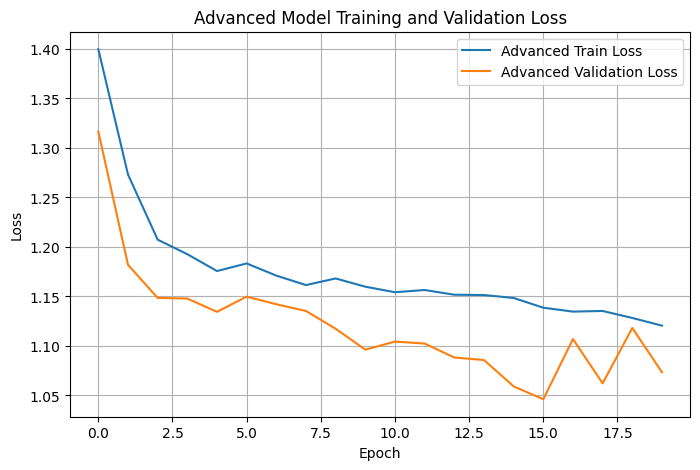

In [58]:
plt.figure(figsize=(8, 5))

plt.plot(advanced_train_losses, label="Advanced Train Loss")
plt.plot(advanced_val_losses, label="Advanced Validation Loss")

plt.title("Advanced Model Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)

plt.show()

# Advanced Model Prediction Results

In this section, we visualize prediction results from the advanced CNN model and compare them with the ground truth masks

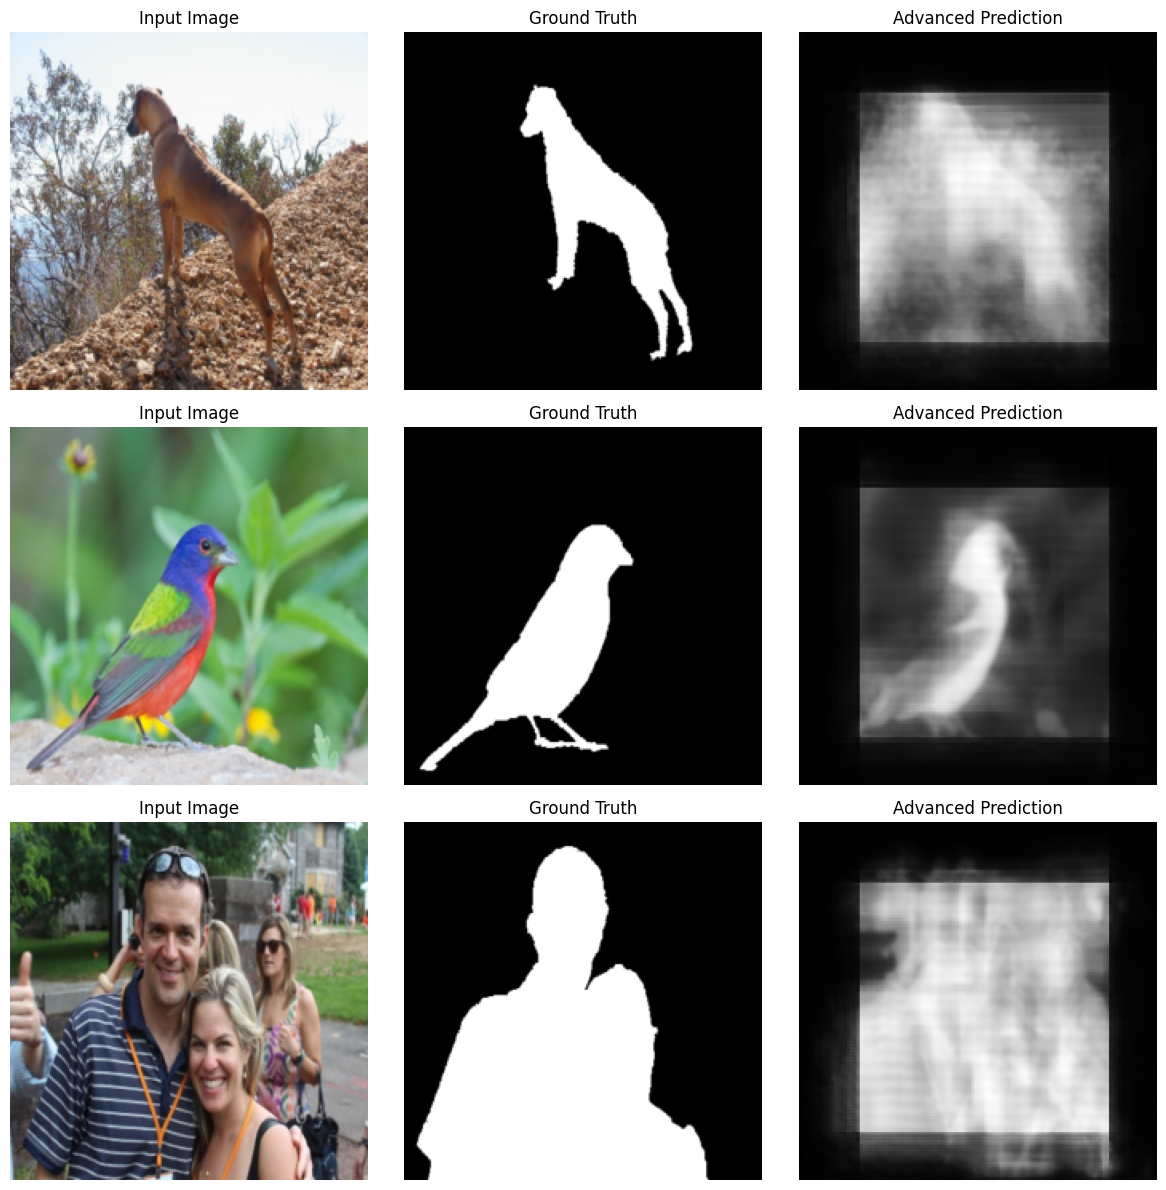

In [59]:
advanced_model.eval()

num_samples = 3

plt.figure(figsize=(12, 12))

for i in range(num_samples):

    sample_image, sample_mask = val_dataset[i]

    input_image = sample_image.unsqueeze(0).to(device)

    with torch.no_grad():
        predicted_mask = advanced_model(input_image)

    predicted_mask = predicted_mask.squeeze().cpu()

    plt.subplot(num_samples, 3, i * 3 + 1)
    plt.imshow(sample_image.permute(1, 2, 0))
    plt.title("Input Image")
    plt.axis("off")

    plt.subplot(num_samples, 3, i * 3 + 2)
    plt.imshow(sample_mask.squeeze(), cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(num_samples, 3, i * 3 + 3)
    plt.imshow(predicted_mask, cmap="gray")
    plt.title("Advanced Prediction")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Advanced Model IoU Evaluation

In this section, we calculate the Intersection-over-Union score for the advanced CNN model

In [60]:
advanced_model.eval()

advanced_iou_scores = []

with torch.no_grad():

    for images, masks in val_loader:

        images = images.to(device)
        masks = masks.to(device)

        predictions = advanced_model(images)

        batch_iou = calculate_iou(predictions, masks)

        advanced_iou_scores.append(batch_iou)

advanced_average_iou = sum(advanced_iou_scores) / len(advanced_iou_scores)

print(f"Advanced Model Average IoU Score: {advanced_average_iou:.4f}")

Advanced Model Average IoU Score: 0.4206


# Advanced Model Precision, Recall and F1 Evaluation

In this section, we evaluate the advanced CNN model using Precision, Recall, and F1-score metrics

In [61]:
advanced_predictions = []
advanced_targets = []

advanced_model.eval()

with torch.no_grad():

    for images, masks in val_loader:

        images = images.to(device)
        masks = masks.to(device)

        predictions = advanced_model(images)

        predictions = (predictions > 0.5).float()
        masks = (masks > 0.5).float()

        advanced_predictions.extend(predictions.cpu().numpy().flatten())
        advanced_targets.extend(masks.cpu().numpy().flatten())

In [62]:
advanced_precision = precision_score(
    advanced_targets,
    advanced_predictions,
    zero_division=0
)

advanced_recall = recall_score(
    advanced_targets,
    advanced_predictions,
    zero_division=0
)

advanced_f1 = f1_score(
    advanced_targets,
    advanced_predictions,
    zero_division=0
)

print(f"Advanced Precision: {advanced_precision:.4f}")
print(f"Advanced Recall: {advanced_recall:.4f}")
print(f"Advanced F1 Score: {advanced_f1:.4f}")

Advanced Precision: 0.5787
Advanced Recall: 0.6102
Advanced F1 Score: 0.5940


# Final Metrics Comparison

In this section, we compare the evaluation results of the previous improved model and the advanced CNN model

In [63]:
import pandas as pd

comparison_data = {
    "Model": ["Improved CNN", "Advanced CNN"],
    "IoU": [average_iou, advanced_average_iou],
    "Precision": [precision, advanced_precision],
    "Recall": [recall, advanced_recall],
    "F1 Score": [f1, advanced_f1]
}

comparison_df = pd.DataFrame(comparison_data)

comparison_df

,Model,IoU,Precision,Recall,F1 Score
0,Improved CNN,0.173814,0.528181,0.195572,0.285449
1,Advanced CNN,0.420591,0.578667,0.610190,0.594011


# Metrics Comparison Visualization

In this section, we visualize the performance differences between the improved CNN model and the advanced CNN model

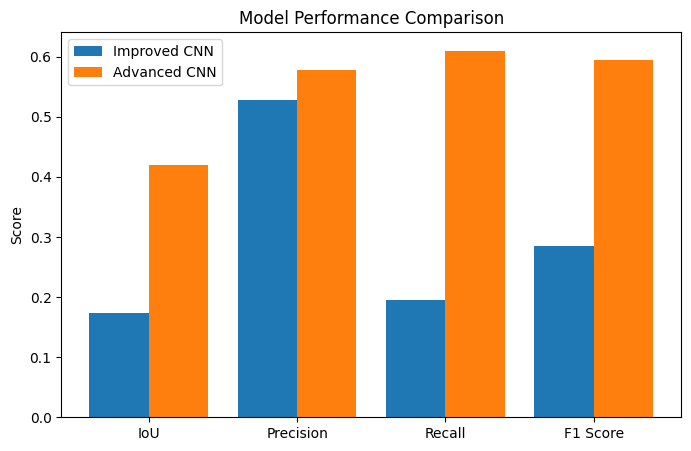

In [64]:
metrics = ["IoU", "Precision", "Recall", "F1 Score"]

improved_scores = [
    average_iou,
    precision,
    recall,
    f1
]

advanced_scores = [
    advanced_average_iou,
    advanced_precision,
    advanced_recall,
    advanced_f1
]

x = range(len(metrics))

plt.figure(figsize=(8, 5))

plt.bar(x, improved_scores, width=0.4, label="Improved CNN")
plt.bar(
    [i + 0.4 for i in x],
    advanced_scores,
    width=0.4,
    label="Advanced CNN"
)

plt.xticks([i + 0.2 for i in x], metrics)

plt.ylabel("Score")
plt.title("Model Performance Comparison")

plt.legend()

plt.show()

# Inference Time Evaluation

In this section, we measure the average inference time required for the advanced CNN model to generate segmentation masks

In [65]:
import time

advanced_model.eval()

sample_image, _ = val_dataset[0]

input_image = sample_image.unsqueeze(0).to(device)

start_time = time.time()

with torch.no_grad():
    prediction = advanced_model(input_image)

end_time = time.time()

inference_time = end_time - start_time

print(f"Inference Time: {inference_time:.4f} seconds")

Inference Time: 0.0067 seconds


# Saving the Final Advanced Model

In this section, we save the final advanced CNN model for future inference and deployment

In [67]:
advanced_model_path = "/content/drive/MyDrive/FocusVision/models/focusvision_advanced_model.pth"

torch.save(advanced_model.state_dict(), advanced_model_path)

print("Advanced model saved successfully")

Advanced model saved successfully
